<a href="https://colab.research.google.com/github/angadpreeta/AI_ML_Project/blob/main/Assignment2_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from sklearn.linear_model import LinearRegression

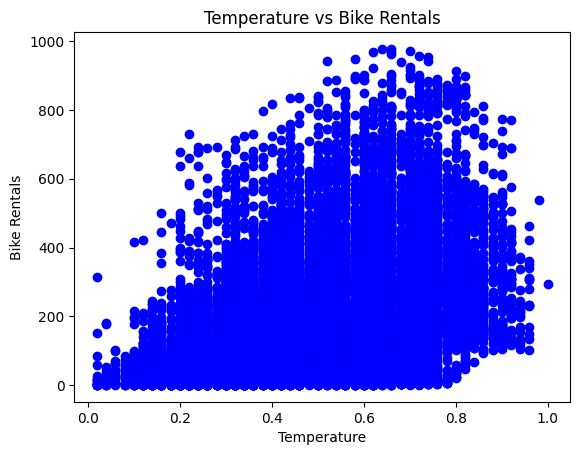

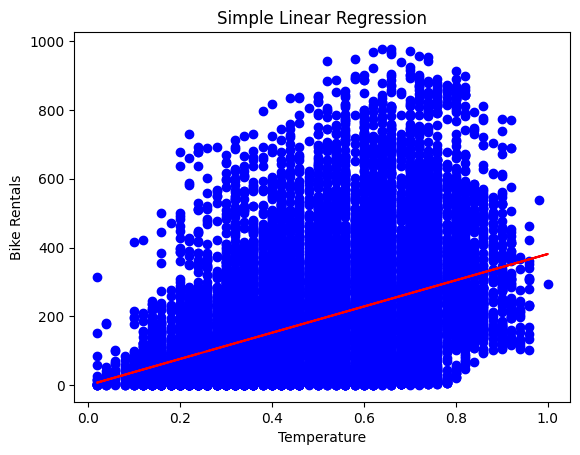

Simple Linear Regression R²: 0.16384059523903438


In [8]:
# Simple Linear Regression
# load dataset and scatterplot

# Data Load
lf = pd.read_csv("hour.csv")

X = lf['temp'].values
y = lf['cnt'].values

plt.scatter(X, y, color= 'blue')
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals")
plt.show()

#fit Simple Linear Regression
X_mat = np.c_[np.ones(len(X)), X]   # Add bias
y_mat = y.reshape(-1, 1)

beta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_mat

#Regression line and R^2

y_pred = X_mat @ beta

plt.scatter(X, y, color= 'blue')
plt.plot(X, y_pred, color='red')
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Simple Linear Regression")
plt.show()

# R-squared
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred.flatten())**2)
r2_simple = 1 - ss_res / ss_total

print("Simple Linear Regression R²:", r2_simple)

In [9]:
#Multi linear Regression
#Train Model
X_multi = lf[['temp', 'atemp', 'hum', 'windspeed']].values
X_multi = np.c_[np.ones(len(X_multi)), X_multi]

beta_multi = np.linalg.inv(X_multi.T @ X_multi) @ X_multi.T @ y_mat

#Prediction
y_pred_multi = X_multi @ beta_multi

Multiple Linear Regression MSE: 24563.141088011096


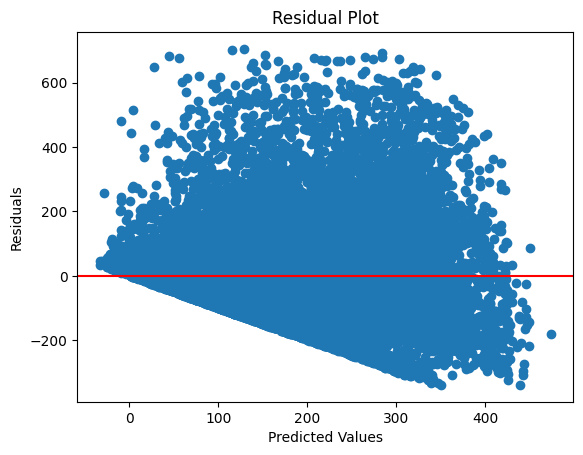

In [10]:
#MSE and Residual Plot for Multi Linear Regression
mse = np.mean((y - y_pred_multi.flatten())**2)
print("Multiple Linear Regression MSE:", mse)

residuals = y - y_pred_multi.flatten()


plt.scatter(y_pred_multi, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [11]:
# Task 3 : Non linear Regression (Polynomial)
#Create feature
temp = lf['temp'].values
temp2 = temp ** 2

#fit NonLinear Model

X_poly = np.c_[np.ones(len(temp)), temp, temp2]

beta_poly = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y_mat
y_pred_poly = X_poly @ beta_poly


Nonlinear Regression R²: 0.16401918198382437


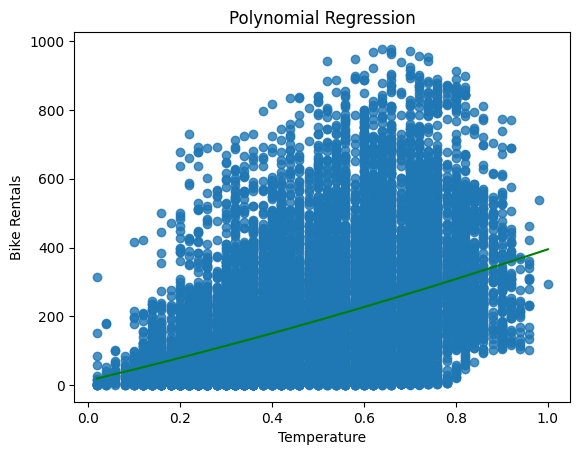

In [12]:
#plot curve and Compare R^2
ss_res_poly = np.sum((y - y_pred_poly.flatten())**2)
r2_poly = 1 - ss_res_poly / ss_total

print("Nonlinear Regression R²:", r2_poly)

sorted_idx = np.argsort(temp)

plt.scatter(temp, y, alpha=0.8)
plt.plot(temp[sorted_idx], y_pred_poly.flatten()[sorted_idx], color='green')
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Polynomial Regression")
plt.show()